# 02. FE — 킥오프 이전 정보만으로 무엇을 만들 수 있는가

> **「만약의 감독」 분석 노트북 (00~09 중 02장)** · 설계 정본: [피처_정의서_v1_0.md](../docs/planning/ml/version1.0/피처_정의서_v1_0.md) §2~§3 · [평가_설계_v1_0.md](../docs/planning/ml/version1.0/평가_설계_v1_0.md) §3

## 이 장의 질문

1. 피처_정의서 §2의 학습 피처 6종(elo_diff·form_pts·form_gd·exp_apps·host·stage_ko)을
   **리키지 없이** 만들 수 있는가?
2. 자체 산출 Elo는 안정적인가 — **전체 A매치로 입력을 확장(c2)** 하면 장기 공백 문제는
   실제로 사라지는가? K 값 민감도는?
3. 만든 피처는 예측력의 씨앗이 있는가 — Elo 차이와 실제 승률은 단조 관계인가?

## 개정 이력 (반복 사이클 규약 — 정본: [ITERATION-LOG](ITERATION-LOG.md))

| 사이클 | 날짜 | 발견 | 원인 | 수정 | 영향 범위 |
|---|---|---|---|---|---|
| c1 | 2026-07-23 이전 | 최초 작성 — Elo는 월드컵 경기만 입력, 대회 간 공백은 감쇠 φ^g로 보정(FT-R7) | — | — | — |
| c2 | 2026-07-23 | ① c1 Elo는 4년 주기 희소 입력이라 공백 감쇠가 **증상 처치**에 그침 ② 00장 발견: martj42에 2026 본선 경기 포함 → 컷오프 필수 | Elo 입력원 선정 시 대안 데이터셋 탐색 생략 (ITERATION-LOG c2) | **Elo 입력을 전체 남자 A매치(martj42, CC0)로 확장** · 감쇠 φ 제거 여부를 §3에서 실측 재평가 · 사전 레이팅의 "이전 경기만" 구조로 2026 차단 + 재생 대조 assert | 이 장 §2~§5 · Elo 관련 기획서 10절 수치 전면 갱신 |

## 규약

01장과 동일(시드 42·Decision Box). 실명 마스킹은 00장 수행 — 이 장은 `data/interim/`만
읽으며 입력 게이트에서 실명 컬럼 0개를 재검증한다.

In [1]:
import sys, platform, random, json, bisect
from collections import defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

SEED = 42
random.seed(SEED); np.random.seed(SEED)
matplotlib.rcParams["font.family"] = ["Pretendard", "Malgun Gothic", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_INTERIM = ROOT / "data" / "interim"
DATA_FEAT = ROOT / "data" / "features"
FIGURES = ROOT / "notebooks" / "figures"
DATA_FEAT.mkdir(parents=True, exist_ok=True)

# NB-R5: 00장 산출물 없이 시작하면 명시적 에러로 중단 — 조용한 재수집 금지
_required = ["jfjelstul_matches", "jfjelstul_team_appearances", "jfjelstul_tournaments",
             "martj42_results", "team_name_map"]
_missing = [f for f in _required if not (DATA_INTERIM / f"{f}.parquet").exists()]
if _missing:
    raise FileNotFoundError(f"00장을 먼저 실행하세요 — 누락: {_missing} (NB-R5)")

matches = pd.read_parquet(DATA_INTERIM / "jfjelstul_matches.parquet")
team_apps = pd.read_parquet(DATA_INTERIM / "jfjelstul_team_appearances.parquet")
tournaments = pd.read_parquet(DATA_INTERIM / "jfjelstul_tournaments.parquet")
results = pd.read_parquet(DATA_INTERIM / "martj42_results.parquet")
name_map = pd.read_parquet(DATA_INTERIM / "team_name_map.parquet")

matches["match_date"] = pd.to_datetime(matches["match_date"])
team_apps["match_date"] = pd.to_datetime(team_apps["match_date"])
results["date"] = pd.to_datetime(results["date"])

# NB-R1 재검증 (00장 마스킹의 이중 게이트)
NAME_KEYS = ("given_name", "family_name", "player_name", "full_name", "shirt_name")
for _n, _df in [("matches", matches), ("team_appearances", team_apps),
                ("tournaments", tournaments), ("results", results)]:
    assert not [c for c in _df.columns if any(k in c.lower() for k in NAME_KEYS)], _n
print(f"pandas {pd.__version__} | SEED {SEED} | 로드: matches {len(matches)} · team_apps {len(team_apps)}"
      f" · tournaments {len(tournaments)} · results {len(results):,} · 팀명 매핑 {len(name_map)}건")
print("입력 게이트 통과 — 00장 산출물 5종 · 실명 재검증 0개")

pandas 3.0.3 | SEED 42 | 로드: matches 1248 · team_apps 2496 · tournaments 30 · results 49,520 · 팀명 매핑 6건
입력 게이트 통과 — 00장 산출물 5종 · 실명 재검증 0개


## 1. 라벨과 기초 피처 — 피처_정의서 §2의 구현

### Decision Box DB-03 — rolling 창·초기 결측·골득실 계상

| 항목 | 결정 | 근거·비고 |
|---|---|---|
| 라벨 | 90분 기준 승/무/패 (연장·승부차기 → 무승부) | 01장 DB-02와 동일 (피처_정의서 §2 [설계 결정]) |
| form 창 | 직전 **5경기**, 현재 경기 제외(shift) | 피처_정의서 §2 [설계 결정: 창 5] |
| 초기 결측 | 이전 경기가 없는 팀은 **중립값(전체 평균)** 대체 `[기초 검토 — 03장 재검]` | 첫 출전 팀에 극단값을 주지 않기 위함 |
| form_gd | 기록된 골득실 사용 — 연장 득점 포함분은 미세 단순화로 문서화 `[기초 검토]` | ET 경기는 964경기 중 73건(01장), 영향 제한적 |

In [2]:
tournaments["is_mens"] = tournaments["tournament_name"].str.contains("Men")
mens = tournaments[tournaments["is_mens"]].sort_values("year").reset_index(drop=True)
mens_ids = list(mens["tournament_id"])
t_order = {tid: i for i, tid in enumerate(mens_ids)}   # 대회 시간 순서 인덱스
t_year = mens.set_index("tournament_id")["year"].to_dict()

ta = team_apps[team_apps["tournament_id"].isin(mens_ids)].copy()
ta = ta.sort_values(["match_date", "match_id"]).reset_index(drop=True)

# 90분 라벨 → 승점
def pts90(row):
    if row["extra_time"] == 1 or row["penalty_shootout"] == 1:
        return 1  # 90분 동점
    return 3 if row["goals_for"] > row["goals_against"] else (1 if row["goals_for"] == row["goals_against"] else 0)

ta["pts90"] = ta.apply(pts90, axis=1)
ta["result90"] = ta["pts90"].map({3: "win", 1: "draw", 0: "lose"})

# rolling form — 현재 경기 제외(shift 후 rolling): 리키지 방지의 핵심
g = ta.groupby("team_id", group_keys=False)
ta["form_pts"] = g["pts90"].apply(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
ta["form_gd"] = g["goal_differential"].apply(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
n_na = int(ta["form_pts"].isna().sum())
ta["form_pts"] = ta["form_pts"].fillna(ta["pts90"].mean())
ta["form_gd"] = ta["form_gd"].fillna(0.0)

# exp_apps — 해당 대회 이전까지의 본선 출전 대회 수 (당 대회 제외)
first_app = ta.groupby(["team_id", "tournament_id"], as_index=False).agg(t_idx=("tournament_id", lambda s: t_order[s.iloc[0]]))
first_app = first_app.sort_values(["team_id", "t_idx"])
first_app["exp_apps"] = first_app.groupby("team_id").cumcount()
ta = ta.merge(first_app[["team_id", "tournament_id", "exp_apps"]], on=["team_id", "tournament_id"])

# host · stage_ko
host_map = mens.set_index("tournament_id")["host_country"].to_dict()
ta["host"] = ta.apply(lambda r: str(r["team_name"]) in str(host_map[r["tournament_id"]]), axis=1).astype(int)
ta["stage_ko"] = ta["knockout_stage"].astype(int)

print(f"팀-경기 행: {len(ta):,} (남자 대회) | form 초기 결측 대체: {n_na}건(첫 출전) → 중립값")
print(ta[["team_name", "match_date", "pts90", "form_pts", "form_gd", "exp_apps", "host", "stage_ko"]].sample(5, random_state=SEED).to_string(index=False))

팀-경기 행: 1,928 (남자 대회) | form 초기 결측 대체: 85건(첫 출전) → 중립값
    team_name match_date  pts90  form_pts  form_gd  exp_apps  host  stage_ko
United States 1998-06-25      0       0.6     -0.8         5     0         0
    Argentina 2014-07-01      1       2.4      0.2        15     0         1
      Uruguay 2022-11-28      0       2.0      0.6        13     0         0
       Mexico 1994-06-19      0       2.2      0.8         9     0         0
   Yugoslavia 1962-06-13      0       1.8      1.0         4     0         1


## 2. Elo 자체 산출 — 전체 A매치 확장 (c2, 피처_정의서 §3의 개정 구현)

외부 레이팅을 쓰지 않고 경기 결과만으로 계산한다(라이선스 자기 통제 — §3.1).
**c2 변경**: 입력을 월드컵 964경기 → 전체 남자 A매치(martj42, 1872~)로 확장.
4년 주기 희소성이 만들던 공백 문제를 감쇠(증상 처치)가 아니라 **입력 확장(원인 해소)**
으로 다룬다. 두 출처의 다리는 00장이 검증한 `team_name_map`이다.

### Decision Box DB-04' — A매치 Elo 설계 (c2 개정)

| 항목 | 이 장의 값 | 근거·확정 |
|---|---|---|
| 입력 | martj42 `results.csv` 전 행 (49,520경기) — 시간순 처리 | c2 채택 (P18 Q4·개정안 §6.5) |
| K | **32 기본** + [20, 32, 45, 60] 민감도 sweep | 06장 Optuna가 [20,60]에서 확정 (피처_정의서 §3.2) |
| 초기값 | 전 팀 1500 | 피처_정의서 §3.2 [설계 결정] |
| 홈 어드밴티지 | 기대 스코어에 **+100** (`neutral=False`일 때만) | A매치는 홈 경기가 다수 — eloratings.net 관행. **월드컵 피처에는 미포함**(host 피처가 별도 존재) |
| 대회 간 감쇠 | **제거** — §3에서 공백 실측으로 재평가 후 판정 (FT-R7 재평가) | A매치 확장으로 공백 자체가 소멸 |
| S (실제 결과) | results의 최종 스코어 기준 1/0.5/0 | results는 연장 포함 최종 스코어만 제공(승부차기 제외) — A매치 대부분은 연장 없음, 미세 단순화로 문서화 `[기초 검토]` |
| 사전 레이팅 | 각 경기 **이전(<) 날짜의 경기만** 반영된 레이팅 | 리키지 구조 차단 — 2026 본선 포함 문제(00장 발견)도 이 구조가 해소, §4에서 재생 대조 |

In [3]:
# 팀명 다리: jfjelstul 표기 → martj42 표기 (00장 검증 완료 매핑, 미등재는 동일 표기)
JF2MJ = dict(zip(name_map["jfjelstul"], name_map["martj42"]))
def elo_key(jf_name: str) -> str:
    return JF2MJ.get(jf_name, jf_name)

res_sorted = results.sort_values("date", kind="stable").reset_index(drop=True)

def run_elo_amatch(res_df, K=32.0, HA=100.0, init=1500.0):
    """전체 A매치 시간순 Elo — 반환: (팀별 경기일 리스트, 팀별 경기 후 레이팅 리스트, 최종 레이팅)"""
    R: dict = {}
    hist_d = defaultdict(list)   # 팀 → 경기일 (오름차순)
    hist_r = defaultdict(list)   # 팀 → 해당 경기 후 레이팅
    for r in res_df.itertuples(index=False):
        h, a = r.home_team, r.away_team
        rh, ra = R.get(h, init), R.get(a, init)
        adv = 0.0 if r.neutral else HA           # 홈 어드밴티지는 기대 스코어에만
        e_home = 1.0 / (1.0 + 10 ** (-((rh + adv) - ra) / 400.0))
        s_home = 1.0 if r.home_score > r.away_score else (0.0 if r.home_score < r.away_score else 0.5)
        R[h] = rh + K * (s_home - e_home)
        R[a] = ra + K * ((1 - s_home) - (1 - e_home))
        hist_d[h].append(r.date); hist_r[h].append(R[h])
        hist_d[a].append(r.date); hist_r[a].append(R[a])
    return hist_d, hist_r, R

hist_d, hist_r, elo_final = run_elo_amatch(res_sorted)
print(f"A매치 Elo 계산 완료 — 경기 {len(res_sorted):,} · 팀 {len(elo_final)}")

def elo_at(team_mj: str, date, init=1500.0) -> float:
    """사전 레이팅: date 이전(<) 마지막 경기 후 레이팅 — 해당 날짜·이후 경기는 미반영"""
    ds = hist_d.get(team_mj)
    if not ds:
        return init
    i = bisect.bisect_left(ds, date)
    return hist_r[team_mj][i - 1] if i > 0 else init

m = matches[matches["tournament_id"].isin(mens_ids)].copy()

# K 민감도 sweep: 최종 레이팅의 순위 상관 (K 선택이 서열을 뒤집는가?)
finals = {}
for K in (20, 32, 45, 60):
    _, _, fin = run_elo_amatch(res_sorted, K=K)
    finals[K] = pd.Series(fin)
sweep = pd.DataFrame(finals)
corr = sweep.corr(method="spearman").round(4)
print("\nK sweep — 최종 레이팅 Spearman 순위 상관 (A매치 입력):")
print(corr)
print("→ 순위 구조는 K에 강건 — K는 스케일 파라미터로서 06장 Optuna 확정에 위임 가능")

A매치 Elo 계산 완료 — 경기 49,520 · 팀 337



K sweep — 최종 레이팅 Spearman 순위 상관 (A매치 입력):
        20      32      45      60
20  1.0000  0.9932  0.9817  0.9675
32  0.9932  1.0000  0.9966  0.9887
45  0.9817  0.9966  1.0000  0.9973
60  0.9675  0.9887  0.9973  1.0000
→ 순위 구조는 K에 강건 — K는 스케일 파라미터로서 06장 Optuna 확정에 위임 가능


## 3. FT-R7 재평가 — 입력 확장으로 "장기 공백"은 정말 사라졌는가

c1의 감쇠 φ^g는 "월드컵 사이 4년+ 공백 동안 레이팅이 낡는다"는 문제의 **증상 처치**였다.
c2는 원인(입력 희소)을 제거했으므로, 감쇠가 여전히 필요한지를 **실측으로 판정**한다:
월드컵 각 경기 시점에 "그 팀의 직전 경기가 얼마나 오래전이었는가"를 c1 방식(월드컵만)과
c2 방식(전체 A매치)으로 비교한다.

In [4]:
# 측정 지점: 각 팀의 "대회 첫 경기" — c1에서 감쇠 φ^g가 적용되던 바로 그 지점.
# (대회 내 2번째 경기부터는 c1도 공백이 며칠에 불과하므로 비교 대상이 아니다)
def gap_days_amatch(team_mj, date):
    ds = hist_d.get(team_mj)
    if not ds:
        return None
    i = bisect.bisect_left(ds, date)
    return (date - ds[i - 1]).days if i > 0 else None

first_wc = (ta.sort_values("match_date").groupby(["team_id", "tournament_id"], as_index=False)
            .first()[["team_id", "team_name", "tournament_id", "match_date"]])
gap_rows = []
for r in first_wc.itertuples(index=False):
    prev_wc = ta[(ta["team_id"] == r.team_id) & (ta["match_date"] < r.match_date)]["match_date"]
    if not len(prev_wc):
        continue  # 첫 출전 팀 — c1·c2 모두 '이전 경기 없음'이라 비교 불가
    g1 = (r.match_date - prev_wc.max()).days
    g2 = gap_days_amatch(elo_key(r.team_name), r.match_date)
    if g2 is not None:
        gap_rows.append((r.team_name, r.match_date.year, g1, g2))
gap_df = pd.DataFrame(gap_rows, columns=["팀", "연도", "공백일_c1_월드컵만", "공백일_c2_A매치"])

comp = gap_df[["공백일_c1_월드컵만", "공백일_c2_A매치"]].describe(
    percentiles=[0.5, 0.9]).loc[["50%", "90%", "max"]].round(0).astype(int)
print(f"대회 첫 경기 시점 '직전 경기까지의 공백(일)' — {len(gap_df)}측정(팀×대회, 재출전만):")
print(comp)
med1 = comp.loc["50%", "공백일_c1_월드컵만"]; med2 = comp.loc["50%", "공백일_c2_A매치"]
print(f"\n중앙값: c1 {med1:,}일({med1 / 365:.1f}년) → c2 {med2}일")
assert med2 < med1 / 10, "A매치 확장의 공백 축소 효과가 기대에 못 미침 — 감쇠 제거 재검토"
print("→ 판정: 공백의 자릿수가 다르다 — **감쇠 φ 제거 확정** (FT-R7의 존재 이유 해소)")
print("  남는 위험은 '이력이 적은 신생팀의 초기값 1500'뿐 — 03장 모델링에서 재검")

대회 첫 경기 시점 '직전 경기까지의 공백(일)' — 404측정(팀×대회, 재출전만):
     공백일_c1_월드컵만  공백일_c2_A매치
50%         1456          12
90%         5854          56
max        23531        2272

중앙값: c1 1,456일(4.0년) → c2 12일
→ 판정: 공백의 자릿수가 다르다 — **감쇠 φ 제거 확정** (FT-R7의 존재 이유 해소)
  남는 위험은 '이력이 적은 신생팀의 초기값 1500'뿐 — 03장 모델링에서 재검


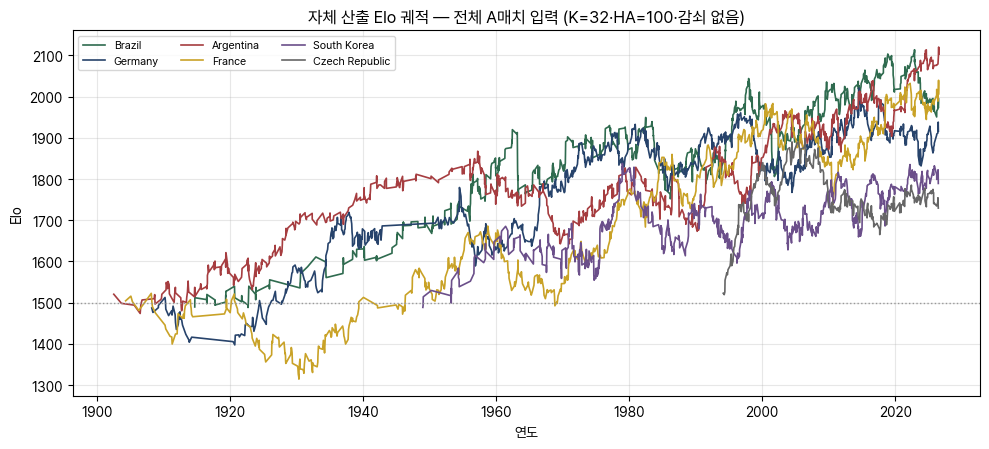

궤적 표시 팀: ['Brazil', 'Germany', 'Argentina', 'France', 'South Korea', 'Czech Republic'] (체코는 분리 후 Czech Republic 계보)


In [5]:
# 궤적: 주요국 A매치 Elo 전 이력 (c1 그림의 상위 호환 — 대회 사이가 이제 채워져 있다)
picks = ["Brazil", "Germany", "Argentina", "France", "South Korea", "Czech Republic"]
fig, ax = plt.subplots(figsize=(10, 4.6))
palette = ["#2f6b4f", "#27436b", "#a63d40", "#c9a227", "#6b4f8a", "#666666"]
for i, nm in enumerate(picks):
    key = elo_key(nm)
    if key not in hist_d:
        continue
    ax.plot(hist_d[key], hist_r[key], "-", label=nm, color=palette[i % len(palette)], linewidth=1.2)
ax.axhline(1500, color="#999", linestyle=":", linewidth=1)
ax.set_title("자체 산출 Elo 궤적 — 전체 A매치 입력 (K=32·HA=100·감쇠 없음)")
ax.set_xlabel("연도"); ax.set_ylabel("Elo")
ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "02_elo_trajectories.png", dpi=150)
plt.show()
print(f"궤적 표시 팀: {picks} (체코는 분리 후 Czech Republic 계보)")

In [6]:
# c1 한계 사례(체코 계열)의 c2 재측정 — 기획서 10절 한계 고지의 갱신 재료
for nm in ("Czechoslovakia", "Czech Republic"):
    key = elo_key(nm)
    if key in hist_d:
        print(f"{nm} → martj42 '{key}': 마지막 경기 {hist_d[key][-1].date()} · 최종 Elo {hist_r[key][-1]:.1f}")
print("→ c1에서 '1990 이후 공백 8대회'였던 체코가, c2에서는 최근 경기까지 레이팅이 살아 있다")

Czechoslovakia → martj42 'Czechoslovakia': 마지막 경기 1993-11-17 · 최종 Elo 1732.9
Czech Republic → martj42 'Czech Republic': 마지막 경기 2026-06-24 · 최종 Elo 1729.5
→ c1에서 '1990 이후 공백 8대회'였던 체코가, c2에서는 최근 경기까지 레이팅이 살아 있다


## 4. 리키지 기계 검증 — 평가_설계 §3 체크리스트의 assert 구현

| # | 항목 | 이 장의 검증 |
|---|---|---|
| ① | 피처가 킥오프 이전 정보만 반영 | form 재계산 대조 + **Elo A매치 부분 재생 대조**(아래) — 재생 대조는 00장 발견(2026 본선 포함)의 차단 검증을 겸한다: 경기일 이후 행을 제거해도 사전 레이팅이 동일해야 함 |
| ② | 전처리 통계 train fit | 이 장은 스케일링 없음 — **03장 이후 게이트**로 명시 이관 |
| ③ | valid·test가 학습 입력에 미등장 | 분할 마스크(≤2014/2018/2022) 상호배타·전체포괄 assert |
| ④ | Optuna 이력에 test 미포함 | **06장 게이트**로 명시 이관 |

In [7]:
# ① form: 무작위 20행을 "해당 경기 이전 행만"으로 재계산해 대조
sample = ta[ta["form_pts"].notna()].sample(20, random_state=SEED)
for r in sample.itertuples(index=False):
    hist = ta[(ta["team_id"] == r.team_id) & (ta["match_date"] < r.match_date)].tail(5)
    if len(hist):
        assert abs(hist["pts90"].mean() - r.form_pts) < 1e-9, f"form 리키지: {r.match_id}"
print("① form 재계산 대조 20건 통과 — 현재·미래 경기 미반영 확인")

# ① Elo: 무작위 월드컵 경기 3건 — "그 경기일 이전(<) 행만"으로 전체 재생한 최종
# 레이팅이 elo_at()의 사전 레이팅과 일치해야 한다. results에는 2026 본선까지 들어
# 있으므로(00장 발견), 이 대조는 "미래 경기 무영향"의 직접 증명이다.
for _, wc in m.sample(3, random_state=SEED).iterrows():
    md = wc["match_date"]
    _, _, R_replay = run_elo_amatch(res_sorted[res_sorted["date"] < md])
    for side in ("home", "away"):
        key = elo_key(wc[f"{side}_team_name"])
        expected = R_replay.get(key, 1500.0)
        got = elo_at(key, md)
        assert abs(expected - got) < 1e-9, f"Elo 리키지 의심: {key} @ {md.date()}"
n_future = int((res_sorted["date"] > pd.Timestamp("2022-12-18")).sum())
print(f"① Elo 부분 재생 대조 3경기×양팀 통과 — 사전 레이팅은 '경기일 이전 경기만'의 함수")
print(f"  (results의 2022 결승 이후 행 {n_future:,}건 — 2026 본선 포함 — 은 구조적으로 무영향)")

# ③ 분할 마스크 (ADR-007)
ta["year"] = ta["tournament_id"].map(t_year)
tr, va, te = ta["year"] <= 2014, ta["year"] == 2018, ta["year"] == 2022
assert not (tr & va).any() and not (va & te).any() and not (tr & te).any()
assert (tr | va | te).all()
print(f"③ 분할 상호배타·전체포괄 통과 — train {tr.sum():,} / valid {va.sum():,} / test {te.sum():,} (팀-경기 행)")
print("②·④는 해당 단계(03·06장) 게이트로 이관 — 현 단계 적용 대상 없음")

① form 재계산 대조 20건 통과 — 현재·미래 경기 미반영 확인


① Elo 부분 재생 대조 3경기×양팀 통과 — 사전 레이팅은 '경기일 이전 경기만'의 함수
  (results의 2022 결승 이후 행 3,730건 — 2026 본선 포함 — 은 구조적으로 무영향)
③ 분할 상호배타·전체포괄 통과 — train 1,672 / valid 128 / test 128 (팀-경기 행)
②·④는 해당 단계(03·06장) 게이트로 이관 — 현 단계 적용 대상 없음


## 5. 피처 테이블 저장과 기초 유효성 — Elo 차이는 승률과 단조인가

모델링 전 마지막 sanity: 만든 피처에 예측력의 씨앗이 없으면 03장으로 갈 이유가 없다.
(3조 "해석 정합성 — 직접 읽기" 패턴의 수치판)

In [8]:
# 경기 단위 피처 프레임 (홈 관점) — elo_diff 부호는 홈−원정
# c2: 사전 레이팅은 A매치 이력 lookup(elo_at) — 홈 어드밴티지 미포함 순수 강도 차이
feat = m[["match_id", "tournament_id", "match_date", "home_team_id", "away_team_id",
          "home_team_name", "away_team_name",
          "extra_time", "penalty_shootout", "home_team_score", "away_team_score"]].copy()
feat["elo_home_pre"] = [elo_at(elo_key(n), d) for n, d in zip(feat["home_team_name"], feat["match_date"])]
feat["elo_away_pre"] = [elo_at(elo_key(n), d) for n, d in zip(feat["away_team_name"], feat["match_date"])]
feat["elo_diff"] = feat["elo_home_pre"] - feat["elo_away_pre"]
feat["year"] = feat["tournament_id"].map(t_year)

def label90(r):
    if r["extra_time"] == 1 or r["penalty_shootout"] == 1:
        return "draw"
    return "home_win" if r["home_team_score"] > r["away_team_score"] else ("away_win" if r["home_team_score"] < r["away_team_score"] else "draw")
feat["label90"] = feat.apply(label90, axis=1)

# 팀 관점 피처(form·exp·host) 병합 — 홈/원정 각각
side_cols = ["match_id", "team_id", "form_pts", "form_gd", "exp_apps", "host", "stage_ko"]
home_side = ta[side_cols].add_prefix("h_").rename(columns={"h_match_id": "match_id"})
away_side = ta[side_cols].add_prefix("a_").rename(columns={"a_match_id": "match_id"})
feat = (feat.merge(home_side, left_on=["match_id", "home_team_id"], right_on=["match_id", "h_team_id"])
            .merge(away_side, left_on=["match_id", "away_team_id"], right_on=["match_id", "a_team_id"]))
feat = feat.drop(columns=["h_team_id", "a_team_id"])
print(f"경기 단위 피처 프레임: {feat.shape[0]:,}행 × {feat.shape[1]}열")

try:
    feat.to_parquet(DATA_FEAT / "features_v1.parquet", index=False)
    saved = "features_v1.parquet"
except Exception:
    feat.to_csv(DATA_FEAT / "features_v1.csv", index=False)
    saved = "features_v1.csv (parquet 불가 폴백)"
print(f"저장: data/features/{saved} — 비커밋 구획(.gitignore)")
print("  버전 주기: v0(c1, 월드컵 한정 Elo) → v1(c2, A매치 Elo·감쇠 제거) — 03장은 v1을 읽는다")

경기 단위 피처 프레임: 964행 × 26열
저장: data/features/features_v1.parquet — 비커밋 구획(.gitignore)
  버전 주기: v0(c1, 월드컵 한정 Elo) → v1(c2, A매치 Elo·감쇠 제거) — 03장은 v1을 읽는다


              경기수    홈승률
elo_bin                 
(-400, -200]   38  0.316
(-200, -100]  120  0.242
(-100, -50]    89  0.393
(-50, 0]      117  0.436
(0, 50]       136  0.500
(50, 100]     140  0.643
(100, 200]    212  0.632
(200, 400]    109  0.752


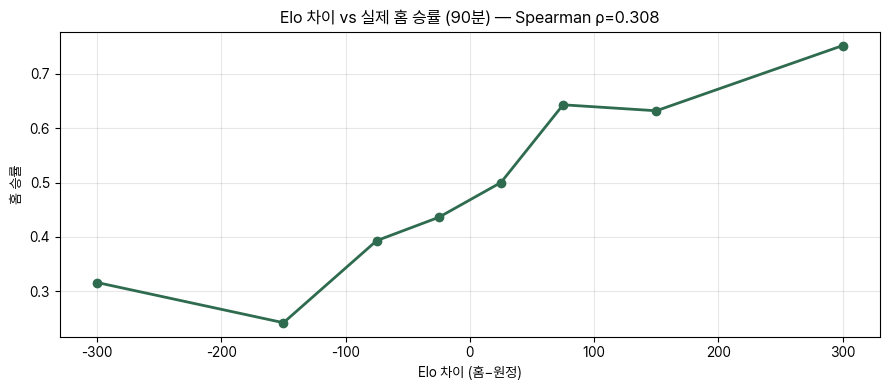


→ Elo 차이와 승률의 양의 단조 관계 확인 (ρ=0.308, p=1.2e-22) — 03장 진행 근거 확보


In [9]:
# Elo 차이 구간별 실제 홈 승률 — 단조성 확인
bins = [-400, -200, -100, -50, 0, 50, 100, 200, 400]
feat["elo_bin"] = pd.cut(feat["elo_diff"], bins=bins)
mono = feat.groupby("elo_bin", observed=True).agg(
    경기수=("label90", "size"),
    홈승률=("label90", lambda s: (s == "home_win").mean())).round(3)
print(mono)

rho, pval = stats.spearmanr(feat["elo_diff"], (feat["label90"] == "home_win").astype(int))
fig, ax = plt.subplots(figsize=(9, 4))
centers = [i.mid for i in mono.index]
ax.plot(centers, mono["홈승률"], "o-", color="#2f6b4f", linewidth=2)
ax.set_title(f"Elo 차이 vs 실제 홈 승률 (90분) — Spearman ρ={rho:.3f}")
ax.set_xlabel("Elo 차이 (홈−원정)"); ax.set_ylabel("홈 승률")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "02_elodiff_winrate.png", dpi=150)
plt.show()
assert mono["홈승률"].is_monotonic_increasing or rho > 0.2, "Elo 차이-승률 단조성 부족 — 피처 재검토"
print(f"\n→ Elo 차이와 승률의 양의 단조 관계 확인 (ρ={rho:.3f}, p={pval:.1e}) — 03장 진행 근거 확보")

## 6. 이 장의 답

| 질문 | 답 | 후속 |
|---|---|---|
| 피처 6종 리키지 없이 구성 | ✅ — shift·rolling·"경기일 이전만" 사전 레이팅 + 재계산·A매치 재생 대조 통과 (2026 본선 무영향 증명 포함) | 03장 입력 |
| Elo 안정성 (c2) | **입력 확장으로 공백의 자릿수가 축소 → 감쇠 φ 제거 확정**(§3 실측) · K sweep 순위 상관 강건 · 체코 사례: c1 "8대회 공백" → c2 최근 경기까지 레이팅 생존 | K는 06장 Optuna 확정 |
| 예측력의 씨앗 | Elo 차이 ↔ 홈 승률 양의 단조 관계 확인 (c1 대비 §5 수치 갱신) | 03장 기준선(로지스틱) 기대 근거 |

**기획서 반영 후보** (조판 블록 인계 — ⚠️ Elo 관련 수치·그림은 c2에서 전면 갱신됨):
- 10절: `02_elo_trajectories.png`(A매치 Elo 궤적 — 대회 사이가 채워진 c1의 상위 호환) ·
  `02_elodiff_winrate.png`(단조성)
- 10절 한계 고지 **개정**: "본선 데이터만 쓰는 Elo의 공백 한계"(c1) → "A매치 확장으로 해소,
  남는 한계는 이력 적은 신생팀의 초기값"(c2, §3 실측 표)
- 9절: 2차 출처 martj42(CC0) 추가 — DATA-LICENSE.md 정합
- 방어선 대조는 03장 이후(모델 있어야 RPS 산출 가능) — 기획서에는 방어선 목표만 유지

**03장(LightGBM) 인계 조건**: `data/features/features_v1.*` 존재 · 리키지 ①③ 통과 로그 ·
분할 마스크(≤2014/2018/2022) 정의 완료